<a href="https://colab.research.google.com/github/leilacielok/market_basket_analysis/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Algorithms for Massive Data - Market-Basket Analysis

## 1. Setup

The notebook is designed to run on Google Colab. Insert your Kaggle credentials before running.

In [1]:
import os
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

from google.colab import userdata
from itertools import combinations
from collections import Counter, defaultdict


In [2]:
# Insert your Kaggle credentials before running
os.environ['KAGGLE_USERNAME'] = "xxxx"
os.environ['KAGGLE_KEY'] = "xxxx"

## 2. Dataset Loading

In [3]:
!kaggle datasets download -d harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows
!unzip -o -q imdb-dataset-of-top-1000-movies-and-tv-shows.zip -d imdb_data

print("Dataset downloaded and extracted.")

Dataset URL: https://www.kaggle.com/datasets/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows
License(s): CC0-1.0
100% 175k/175k [00:00<00:00, 24.1MB/s]

Dataset downloaded and extracted.


In [4]:
csv_path = os.path.join(
    "imdb_data",
    "imdb_top_1000.csv"
)

df = pd.read_csv(csv_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1000, 16)


,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


## 3. Global Parameters and Basket Construction

In [5]:
MIN_SUPPORT_RATIO = 0.005
MIN_SUPPORT_COUNT = int(len(df) * MIN_SUPPORT_RATIO)

N_BUCKETS = 100
N_RUNS = 50
N_CHUNKS = 4

In [6]:
STAR_COLS = ["Star1", "Star2", "Star3", "Star4"]

baskets = []

for _, row in df.iterrows():
    basket = set()

    for col in STAR_COLS:
        actor = row[col]
        basket.add(actor)

    baskets.append(basket)

print("Number of baskets:", len(baskets))
print("Example basket:", baskets[0])

Number of baskets: 1000
Example basket: {'Tim Robbins', 'Bob Gunton', 'Morgan Freeman', 'William Sadler'}


## 4. Common Helper: Frequent Singletons

In [7]:
def find_frequent_singletons(baskets, support_threshold):

    names2int = {}
    int2names = {}
    item_id = 0

    for basket in baskets:
        for item in basket:
            if item not in names2int:
                names2int[item] = item_id
                int2names[item_id] = item
                item_id += 1

    counts = [0] * len(names2int)

    for basket in baskets:
        for item in basket:
            item_integer = names2int[item]
            counts[item_integer] += 1

    frequent_items_table = [0] * len(counts)
    frequent_singletons = {}

    new_number = 1
    newint2name = {}

    for item_integer, count in enumerate(counts):
        if count >= support_threshold:
            frequent_items_table[item_integer] = new_number
            newint2name[new_number] = int2names[item_integer]
            frequent_singletons[frozenset([int2names[item_integer]])] = count
            new_number += 1

    return names2int, frequent_items_table, newint2name, frequent_singletons

## 5. A-Priori Algorithm

In [8]:
def find_frequent_pairs_apriori(
    baskets,
    support_threshold,
    names2int,
    frequent_items_table,
    newint2name
):

    pair_counts = {}

    for basket in baskets:

        frequent_items_in_basket = []

        for item in basket:
            old_integer = names2int[item]
            new_integer = frequent_items_table[old_integer]

            if new_integer != 0:
                frequent_items_in_basket.append(new_integer)

        for i in range(len(frequent_items_in_basket)):
            for j in range(i + 1, len(frequent_items_in_basket)):

                item1 = frequent_items_in_basket[i]
                item2 = frequent_items_in_basket[j]

                pair = tuple(sorted((item1, item2)))

                pair_counts[pair] = pair_counts.get(pair, 0) + 1

    frequent_pairs = {}

    for pair, count in pair_counts.items():
        if count >= support_threshold:
            actor1 = newint2name[pair[0]]
            actor2 = newint2name[pair[1]]

            frequent_pairs[frozenset([actor1, actor2])] = count

    return frequent_pairs

## 6. Park, Chen and Yu (PCY) Algorithm

In [9]:
def hash_pair(item1, item2, n_buckets):

    item1, item2 = sorted((item1, item2))
    hash_value = item1 * 31 + item2
    bucket = hash_value % n_buckets

    return bucket

In [10]:
def find_frequent_pairs_pcy(
    baskets,
    support_threshold,
    names2int,
    frequent_items_table,
    newint2name,
    n_buckets=N_BUCKETS,
    show_bucket_stats=False
):

    # FIRST PCY PASS
    # Count buckets for pairs of frequent items
    bucket_counts = [0] * n_buckets

    for basket in baskets:

        frequent_items_in_basket = []

        for item in basket:
            old_integer = names2int[item]
            new_integer = frequent_items_table[old_integer]

            if new_integer != 0:
                frequent_items_in_basket.append(new_integer)

        for i in range(len(frequent_items_in_basket)):
            for j in range(i + 1, len(frequent_items_in_basket)):

                item1 = frequent_items_in_basket[i]
                item2 = frequent_items_in_basket[j]

                bucket = hash_pair(item1, item2, n_buckets)

                bucket_counts[bucket] += 1

    # Bitmap of frequent buckets
    frequent_buckets = [
        count >= support_threshold
        for count in bucket_counts
    ]

    if show_bucket_stats:
      print(
          "Bucket average count:",
          round(sum(bucket_counts) / len(bucket_counts), 2))

      print(
          "Bucket max count:",
          max(bucket_counts))

      plt.hist(bucket_counts, bins=30)
      plt.xlabel("Bucket count")
      plt.ylabel("Number of buckets")
      plt.title("Distribution of bucket counts")

      plt.show()

    # SECOND PCY PASS
    # Count only pairs whose bucket is frequent
    pair_counts = {}

    for basket in baskets:

        frequent_items_in_basket = []

        for item in basket:
            old_integer = names2int[item]
            new_integer = frequent_items_table[old_integer]

            if new_integer != 0:
                frequent_items_in_basket.append(new_integer)

        for i in range(len(frequent_items_in_basket)):
            for j in range(i + 1, len(frequent_items_in_basket)):

                item1 = frequent_items_in_basket[i]
                item2 = frequent_items_in_basket[j]

                pair = tuple(sorted((item1, item2)))
                bucket = hash_pair(item1, item2, n_buckets)

                if frequent_buckets[bucket]:

                    pair_counts[pair] = pair_counts.get(pair, 0) + 1

    frequent_pairs = {}

    for pair, count in pair_counts.items():
        if count >= support_threshold:

            actor1 = newint2name[pair[0]]
            actor2 = newint2name[pair[1]]

            frequent_pairs[frozenset([actor1, actor2])] = count

    return frequent_pairs

## 7. Frequent triples

This block is shared by Apriori, PCY and SON. It counts a triple only if all its pair subsets are frequent.

In [11]:
def find_frequent_triples(
    baskets,
    support_threshold,
    names2int,
    frequent_items_table,
    frequent_pairs
):

    triple_counts = {}

    frequent_pair_sets = set(frequent_pairs.keys())

    for basket in baskets:

        frequent_items_in_basket = []

        for item in basket:
            old_integer = names2int[item]
            new_integer = frequent_items_table[old_integer]

            if new_integer != 0:
                frequent_items_in_basket.append(item)

        for triple in combinations(frequent_items_in_basket, 3):

            triple = frozenset(triple)

            if all(
                frozenset(pair) in frequent_pair_sets
                for pair in combinations(triple, 2)
            ):
                triple_counts[triple] = triple_counts.get(triple, 0) + 1

    frequent_triples = {}

    for triple, count in triple_counts.items():
        if count >= support_threshold:
            frequent_triples[triple] = count

    return frequent_triples

## 8. Algorithm Wrappers

The following wrappers return dictionaries of frequent itemsets grouped by size: `1`, `2` and `3`.

In [12]:
def apriori(baskets, support_threshold):

    (
        names2int,
        frequent_items_table,
        newint2name,
        frequent_singletons
    ) = find_frequent_singletons(baskets, support_threshold)

    frequent_pairs = find_frequent_pairs_apriori(
        baskets,
        support_threshold,
        names2int,
        frequent_items_table,
        newint2name
    )

    frequent_triples = find_frequent_triples(
        baskets,
        support_threshold,
        names2int,
        frequent_items_table,
        frequent_pairs
    )

    frequent_itemsets = {}

    frequent_itemsets[1] = frequent_singletons

    if frequent_pairs:
        frequent_itemsets[2] = frequent_pairs

    if frequent_triples:
        frequent_itemsets[3] = frequent_triples

    return frequent_itemsets

In [13]:
def pcy(baskets, support_threshold, n_buckets=100, show_bucket_stats=False):

    (
        names2int,
        frequent_items_table,
        newint2name,
        frequent_singletons
    ) = find_frequent_singletons(baskets, support_threshold)

    frequent_pairs = find_frequent_pairs_pcy(
        baskets,
        support_threshold,
        names2int,
        frequent_items_table,
        newint2name,
        n_buckets=n_buckets,
        show_bucket_stats=show_bucket_stats
    )

    frequent_triples = find_frequent_triples(
        baskets,
        support_threshold,
        names2int,
        frequent_items_table,
        frequent_pairs
    )

    frequent_itemsets = {}
    frequent_itemsets[1] = frequent_singletons

    if frequent_pairs:
        frequent_itemsets[2] = frequent_pairs

    if frequent_triples:
        frequent_itemsets[3] = frequent_triples

    return frequent_itemsets

## 9. SON Algorithm

Chunk are mined locally using Apriori algorithm. The local support threshold is proportional to the chunk size.

In [14]:
def son(baskets, support_count, n_chunks=4):

    chunk_size = int(np.ceil(len(baskets) / n_chunks))

    all_candidates = {
        1: set(),
        2: set(),
        3: set()
    }

    # Pass 1: local Apriori on chunks
    for i in range(n_chunks):
        chunk = baskets[i * chunk_size : (i + 1) * chunk_size]

        if len(chunk) == 0:
            continue

        local_support = int(np.ceil(support_count * len(chunk) / len(baskets)))

        local_frequent_itemsets = apriori(
            chunk,
            local_support)

        for k in [1, 2, 3]:
            all_candidates[k].update(
                local_frequent_itemsets.get(k, {}).keys())

    # Pass 2: global counting of alla candidates
    candidate_counts = {
        1: defaultdict(int),
        2: defaultdict(int),
        3: defaultdict(int)
    }

    for basket in baskets:
        basket = set(basket)

        for k in [1, 2, 3]:
            for candidate in all_candidates[k]:
                if candidate.issubset(basket):
                    candidate_counts[k][candidate] += 1

    # Keep only globally frequent itemsets
    frequent_itemsets = {
        1: {},
        2: {},
        3: {}
    }

    for k in [1, 2, 3]:
        frequent_itemsets[k] = {
            itemset: count
            for itemset, count in candidate_counts[k].items()
            if count >= support_count
        }

    return frequent_itemsets

## 10. Run the Algorithms

In [15]:
frequent_itemsets_apriori = apriori(
    baskets,
    MIN_SUPPORT_COUNT
)

frequent_itemsets_pcy = pcy(
    baskets,
    MIN_SUPPORT_COUNT,
    n_buckets=N_BUCKETS,
    show_bucket_stats=False
)

frequent_itemsets_son = son(
    baskets,
    MIN_SUPPORT_COUNT,
    n_chunks=N_CHUNKS
)

In [16]:
def show_itemsets(frequent_itemsets):
    return pd.DataFrame(
        [
            {
                "size": k,
                "itemset": ", ".join(sorted(itemset)),
                "support": support
            }
            for k in [1, 2, 3]
            for itemset, support in frequent_itemsets.get(k, {}).items()
        ]
    ).sort_values(
        ["size", "support"],
        ascending=[True, False]
    )

for name, itemsets in [
    ("Apriori", frequent_itemsets_apriori),
    ("PCY", frequent_itemsets_pcy),
    ("SON", frequent_itemsets_son)
]:
    print(f"\n{name}")
    display(show_itemsets(itemsets))


Apriori


,size,itemset,support
5,1,Robert De Niro,17
13,1,Tom Hanks,14
2,1,Al Pacino,13
11,1,Brad Pitt,12
14,1,Clint Eastwood,12
...,...,...,...
73,1,Woody Allen,5
81,2,"Daniel Radcliffe, Rupert Grint",6
79,2,"Emma Watson, Rupert Grint",5
80,2,"Daniel Radcliffe, Emma Watson",5



PCY


,size,itemset,support
5,1,Robert De Niro,17
13,1,Tom Hanks,14
2,1,Al Pacino,13
11,1,Brad Pitt,12
14,1,Clint Eastwood,12
...,...,...,...
73,1,Woody Allen,5
81,2,"Daniel Radcliffe, Rupert Grint",6
79,2,"Emma Watson, Rupert Grint",5
80,2,"Daniel Radcliffe, Emma Watson",5



SON


,size,itemset,support
5,1,Robert De Niro,17
13,1,Tom Hanks,14
1,1,Al Pacino,13
12,1,Brad Pitt,12
14,1,Clint Eastwood,12
...,...,...,...
73,1,Woody Allen,5
79,2,"Daniel Radcliffe, Rupert Grint",6
80,2,"Emma Watson, Rupert Grint",5
81,2,"Daniel Radcliffe, Emma Watson",5


## 11. Scalability Experiment

The following experiment compares the average execution time of Apriori, PCY and SON for different support ratios. Each configuration is repeated `N_RUNS` times and the average execution time is reported.

In [17]:
support_ratios = [0.05, 0.01, 0.005, 0.002]

results = []

for ratio in support_ratios:

    support_count = int(len(baskets) * ratio)

    apriori_times = []
    pcy_times = []
    son_times = []

    for _ in range(N_RUNS):

      # APRIORI
      start = time.time()

      frequent_itemsets_apriori = apriori(
          baskets,
          support_count
      )

      apriori_times.append(time.time() - start)

      # PCY
      start = time.time()

      frequent_itemsets_pcy = pcy(
          baskets,
          support_count,
          n_buckets=N_BUCKETS,
          show_bucket_stats=False
      )

      pcy_times.append(time.time() - start)

      # SON
      start = time.time()

      frequent_itemsets_son = son(
          baskets,
          support_count,
          n_chunks=N_CHUNKS
      )

      son_times.append(time.time() - start)

    apriori_time = sum(apriori_times) / N_RUNS
    pcy_time = sum(pcy_times) / N_RUNS
    son_time = sum(son_times) / N_RUNS

    n_frequent_1 = len(frequent_itemsets_apriori.get(1, {}))
    n_frequent_2 = len(frequent_itemsets_apriori.get(2, {}))
    n_frequent_3 = len(frequent_itemsets_apriori.get(3, {}))

    total_itemsets = (
        n_frequent_1 +
        n_frequent_2 +
        n_frequent_3
    )

    results.append({
        "support_ratio": ratio,
        "support_count": support_count,
        "apriori_time": apriori_time,
        "pcy_time": pcy_time,
        "son_time": son_time,
        "frequent_singletons": n_frequent_1,
        "frequent_pairs": n_frequent_2,
        "frequent_triples": n_frequent_3,
        "total_itemsets": total_itemsets
    })

results_df = pd.DataFrame(results)

results_df.round(4)

,support_ratio,support_count,apriori_time,pcy_time,son_time,frequent_singletons,frequent_pairs,frequent_triples,total_itemsets
0,0.050,50,0.0069,0.0087,0.0084,0,0,0,0
1,0.010,10,0.0109,0.0125,0.0467,9,0,0,9
2,0.005,5,0.0036,0.0046,0.0444,79,3,1,83
3,0.002,2,0.0065,0.0103,1.4955,641,121,25,787


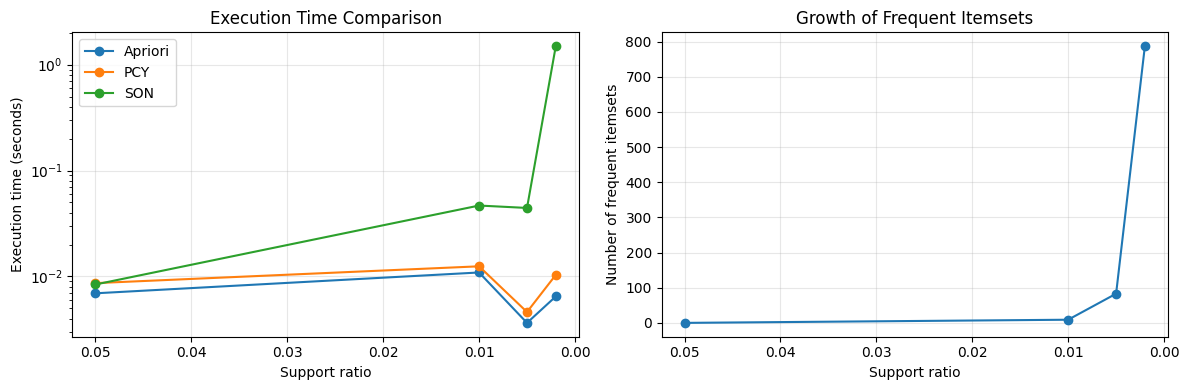

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Comparison of execution times

axes[0].plot(
    results_df["support_ratio"],
    results_df["apriori_time"],
    marker="o",
    label="Apriori"
)

axes[0].plot(
    results_df["support_ratio"],
    results_df["pcy_time"],
    marker="o",
    label="PCY"
)

axes[0].plot(
    results_df["support_ratio"],
    results_df["son_time"],
    marker="o",
    label="SON"
)

axes[0].set_yscale("log")
axes[0].invert_xaxis()
axes[0].set_xlabel("Support ratio")
axes[0].set_ylabel("Execution time (seconds)")
axes[0].set_title("Execution Time Comparison")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Number of frequent itemsets

axes[1].plot(
    results_df["support_ratio"],
    results_df["total_itemsets"],
    marker="o"
)

axes[1].invert_xaxis()
axes[1].set_xlabel("Support ratio")
axes[1].set_ylabel("Number of frequent itemsets")
axes[1].set_title("Growth of Frequent Itemsets")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 12. PCY Parameter Experiment: Number of Buckets

This expetiment measures how the number of hash buckets affects PCY execution time.

In [19]:
bucket_results = []

for n_buckets in [100, 500, 1000, 5000, 10000]:
    times = []

    for _ in range(N_RUNS):

        start = time.time()

        pcy(
            baskets,
            MIN_SUPPORT_COUNT,
            n_buckets=n_buckets,
            show_bucket_stats=False
        )

        times.append(time.time() - start)

    avg_time = sum(times) / N_RUNS

    bucket_results.append({
        "n_buckets": n_buckets,
        "pcy_time": avg_time
    })

bucket_results_df = pd.DataFrame(bucket_results)

bucket_results_df.round(4)

,n_buckets,pcy_time
0,100,0.0037
1,500,0.0040
2,1000,0.0038
3,5000,0.0038
4,10000,0.0039


## 13. SON Parameter Experiment: Number of Chunks

This experiment measures how the number of partitions affects SON execution time#.

In [20]:
chunk_results = []

for n_chunks in [4, 10, 20]:
    times = []

    for _ in range(N_RUNS):

        start = time.time()

        son(
            baskets,
            MIN_SUPPORT_COUNT,
            n_chunks=n_chunks
        )

        times.append(time.time() - start)

    avg_time = sum(times) / N_RUNS

    chunk_results.append({
        "n_chunks": n_chunks,
        "son_time": avg_time
    })

chunk_results_df = pd.DataFrame(chunk_results)

chunk_results_df.round(4)

,n_chunks,son_time
0,4,0.0396
1,10,1.5685
2,20,1.4920


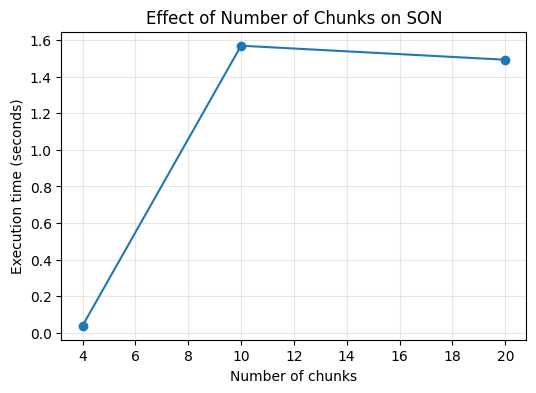

In [21]:
plt.figure(figsize=(6, 4))

plt.plot(
    chunk_results_df["n_chunks"],
    chunk_results_df["son_time"],
    marker="o"
)

plt.xlabel("Number of chunks")
plt.ylabel("Execution time (seconds)")
plt.title("Effect of Number of Chunks on SON")
plt.grid(True, alpha=0.3)

plt.show()
